# 01 — Classical Baseline

Feature engineering (time-domain, frequency-domain, envelope-spectrum statistics) on CWRU
bearing vibration windows, then a Random Forest and an SVM classifier as the classical ML
baseline for fault-type classification. See [docs/datasets.md](../docs/datasets.md) for the
dataset and [docs/phase1_results.md](../docs/phase1_results.md) for the write-up of results.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.cwru import build_windowed_dataset, list_cwru_files, SAMPLE_RATE_HZ
from src.data.features import build_feature_matrix
from src.models.baseline import (
    time_contiguous_split,
    held_out_files_split,
    train_random_forest,
    train_svm,
    evaluate,
)

CWRU_DIR = Path.cwd().parent / "data" / "raw" / "cwru"
WINDOW_SIZE = 2048


## Load and window the raw signals

In [2]:
windows, labels, loads, file_ids = build_windowed_dataset(CWRU_DIR, window_size=WINDOW_SIZE)
print("windows:", windows.shape)
print("label counts:")
print(pd.Series(labels).value_counts())


windows: (1537, 2048)
label counts:
Normal    828
IR007     237
B007       59
B014       59
B021       59
IR014      59
IR021      59
OR007      59
OR014      59
OR021      59
Name: count, dtype: int64


## Extract features

In [3]:
features_df = build_feature_matrix(windows, fs=SAMPLE_RATE_HZ)
features_df.shape


(1537, 21)

In [4]:
features_df.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
td_mean,0.012834,0.007036,-0.011169,5.080444e-02
td_std,0.176960,0.172775,0.059126,7.145687e-01
td_rms,0.177935,0.172393,0.060376,7.148043e-01
td_peak,0.934590,1.189399,0.175863,6.652937e+00
td_peak_to_peak,1.763386,2.255930,0.342546,1.267278e+01
td_skew,-0.043663,0.153182,-0.406679,7.847672e-01
td_kurtosis,2.305172,5.044899,-0.560307,2.720468e+01
td_crest_factor,4.270866,1.607341,2.646803,1.115398e+01
td_shape_factor,1.344725,0.178679,1.210799,2.127835e+00
td_impulse_factor,5.995891,3.340683,3.236925,2.122275e+01


## Primary evaluation: 10-class fault classification (load 0)

Only load-0 files exist for most fault types, so the split holds out the **last 20% of each
file's windows in time order** (see `time_contiguous_split` in
[src/models/baseline.py](../src/models/baseline.py)) rather than a random shuffle — this keeps
train and test from sharing near-identical, highly-correlated windows of the same recording.


In [5]:
load0_mask = loads == 0
X_load0 = features_df[load0_mask].reset_index(drop=True)
y_load0 = labels[load0_mask]
file_ids_load0 = file_ids[load0_mask]

train_mask, test_mask = time_contiguous_split(file_ids_load0, test_fraction=0.2)
X_train, X_test = X_load0[train_mask], X_load0[test_mask]
y_train, y_test = y_load0[train_mask], y_load0[test_mask]
print("train:", X_train.shape, "test:", X_test.shape)


train: (518, 21) test: (132, 21)


In [6]:
rf_model = train_random_forest(X_train, y_train)
rf_results = evaluate(rf_model, X_test, y_test)
print(rf_results["report"])


              precision    recall  f1-score   support

        B007       1.00      1.00      1.00        12
        B014       1.00      0.92      0.96        12
        B021       0.80      1.00      0.89        12
       IR007       1.00      1.00      1.00        12
       IR014       1.00      1.00      1.00        12
       IR021       1.00      1.00      1.00        12
      Normal       1.00      1.00      1.00        24
       OR007       1.00      1.00      1.00        12
       OR014       1.00      0.83      0.91        12
       OR021       1.00      1.00      1.00        12

    accuracy                           0.98       132
   macro avg       0.98      0.97      0.98       132
weighted avg       0.98      0.98      0.98       132



In [7]:
svm_model = train_svm(X_train, y_train)
svm_results = evaluate(svm_model, X_test, y_test)
print(svm_results["report"])


              precision    recall  f1-score   support

        B007       1.00      1.00      1.00        12
        B014       1.00      0.92      0.96        12
        B021       0.86      1.00      0.92        12
       IR007       1.00      1.00      1.00        12
       IR014       1.00      1.00      1.00        12
       IR021       1.00      1.00      1.00        12
      Normal       1.00      1.00      1.00        24
       OR007       1.00      1.00      1.00        12
       OR014       1.00      0.92      0.96        12
       OR021       1.00      1.00      1.00        12

    accuracy                           0.98       132
   macro avg       0.99      0.98      0.98       132
weighted avg       0.99      0.98      0.99       132



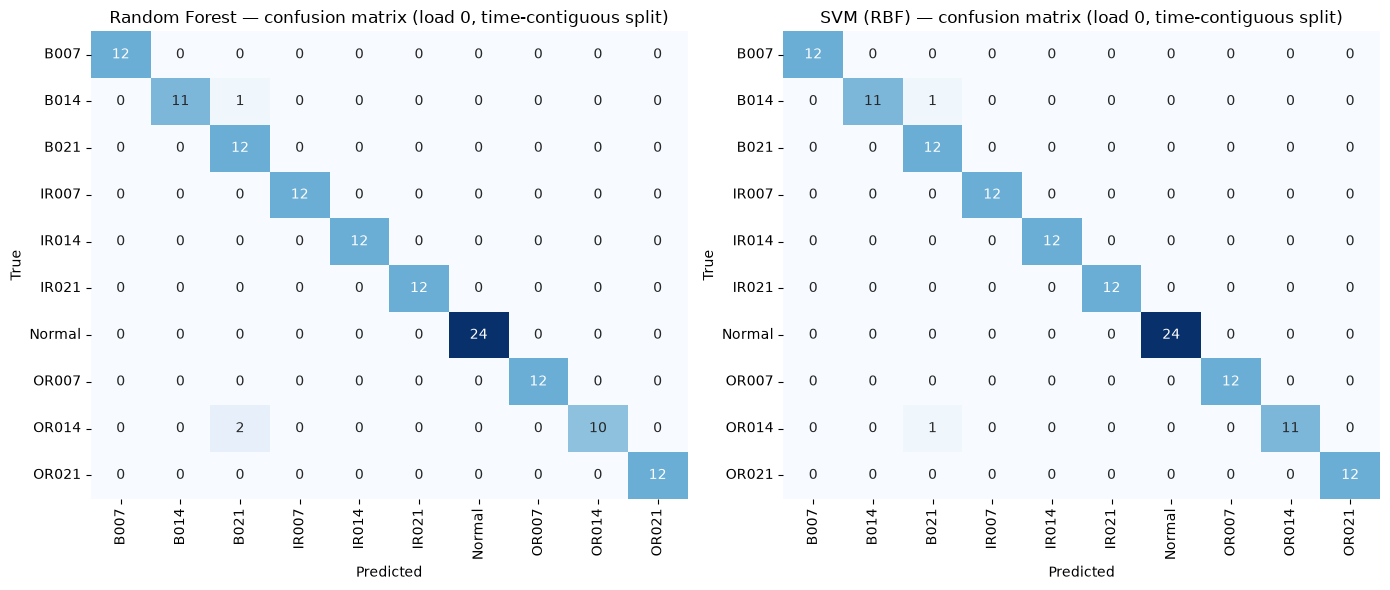

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, results, title in [
    (axes[0], rf_results, "Random Forest"),
    (axes[1], svm_results, "SVM (RBF)"),
]:
    sns.heatmap(
        results["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
        xticklabels=results["labels"], yticklabels=results["labels"], ax=ax, cbar=False,
    )
    ax.set_title(f"{title} — confusion matrix (load 0, time-contiguous split)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "phase1_confusion_matrices.png", dpi=150)
plt.show()


## Leakage check: random window split vs. time-contiguous split

Demonstrates why `docs/datasets.md` calls for a leakage-aware split: a naive random split of
windows (ignoring which file they came from) lets the model see windows from the same
recording in both train and test, inflating accuracy relative to the more realistic
time-contiguous split above.


In [9]:
from sklearn.model_selection import train_test_split

X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky = train_test_split(
    X_load0, y_load0, test_size=0.2, random_state=42, stratify=y_load0
)
leaky_model = train_random_forest(X_train_leaky, y_train_leaky)
leaky_results = evaluate(leaky_model, X_test_leaky, y_test_leaky)

print(f"Random Forest accuracy — time-contiguous split: {rf_results['report_dict']['accuracy']:.3f}")
print(f"Random Forest accuracy — naive random split:      {leaky_results['report_dict']['accuracy']:.3f}")


Random Forest accuracy — time-contiguous split: 0.977
Random Forest accuracy — naive random split:      0.985


## Secondary evaluation: cross-load generalization (IR007, held-out load)

`IR007` and `Normal` were downloaded across all 4 loads specifically for this: train on loads
0-2, test entirely on the held-out load 3 file (`held_out_files_split`) to check whether
features generalize across operating conditions rather than just within one.


In [10]:
ir007_normal_mask = np.isin(labels, ["IR007", "Normal"])
X_cross = features_df[ir007_normal_mask].reset_index(drop=True)
y_cross = labels[ir007_normal_mask]
loads_cross = loads[ir007_normal_mask]
file_ids_cross = file_ids[ir007_normal_mask]

test_files = set(file_ids_cross[loads_cross == 3])
train_mask_c, test_mask_c = held_out_files_split(file_ids_cross, test_files)

X_train_c, X_test_c = X_cross[train_mask_c], X_cross[test_mask_c]
y_train_c, y_test_c = y_cross[train_mask_c], y_cross[test_mask_c]
print("train loads:", sorted(set(loads_cross[train_mask_c])), "| test loads:", sorted(set(loads_cross[test_mask_c])))

cross_model = train_random_forest(X_train_c, y_train_c)
cross_results = evaluate(cross_model, X_test_c, y_test_c)
print(cross_results["report"])


train loads: [np.int64(0), np.int64(1), np.int64(2)] | test loads: [np.int64(3)]


              precision    recall  f1-score   support

       IR007       1.00      1.00      1.00        60
      Normal       1.00      1.00      1.00       237

    accuracy                           1.00       297
   macro avg       1.00      1.00      1.00       297
weighted avg       1.00      1.00      1.00       297

